<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/Stability006.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 12%|█▏        | 603/5000 [00:00<00:06, 647.95it/s]

t = 500, λ_dom ≈ 100.00


 22%|██▏       | 1101/5000 [00:01<00:06, 568.41it/s]

t = 1000, λ_dom ≈ 100.00


 31%|███       | 1540/5000 [00:03<00:11, 304.37it/s]

...

t = 4000, λ_dom ≈ 100.00


 92%|█████████▏| 4611/5000 [00:11<00:00, 792.86it/s]

t = 4500, λ_dom ≈ 100.00


100%|██████████| 5000/5000 [00:11<00:00, 425.69it/s]


t = 5000, λ_dom ≈ 100.00


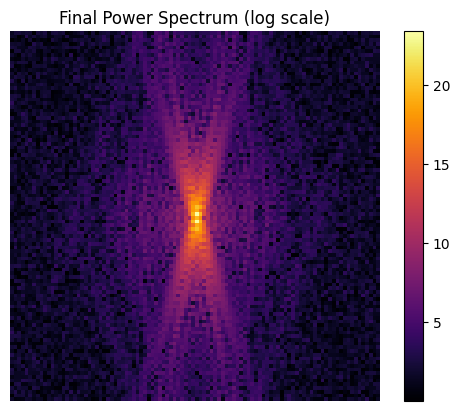


Stability006 complete. Final λ_dom ≈ 100.00

Tracked λ_dom over time:
t = 500, λ_dom ≈ 100.00
t = 1000, λ_dom ≈ 100.00
t = 1500, λ_dom ≈ 100.00
t = 2000, λ_dom ≈ 100.00
t = 2500, λ_dom ≈ 100.00
t = 3000, λ_dom ≈ 100.00
t = 3500, λ_dom ≈ 100.00
t = 4000, λ_dom ≈ 100.00
t = 4500, λ_dom ≈ 100.00
t = 5000, λ_dom ≈ 100.00


In [1]:
# Stability006 — Act XXXIV: The Temporal Persistence Test
# Long-term evolution of 2D macro-scale attractor (alpha=0.1, gamma=0.2)

import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft2, fftshift
from tqdm import tqdm

# --- Parameters ---
alpha, beta, gamma, delta = 0.1, 0.01, 0.2, 0.02
T_max = 5000
L = 100
seed = 42
track_interval = 500  # Track lambda_dom every 500 steps

# --- Initialize Field ---
np.random.seed(seed)
Phi = np.random.randn(L, L)

# --- Laplacian Function ---
def laplacian(Phi):
    return (
        np.roll(Phi, 1, axis=0) + np.roll(Phi, -1, axis=0) +
        np.roll(Phi, 1, axis=1) + np.roll(Phi, -1, axis=1) -
        4 * Phi
    )

# --- Lambda Extraction ---
def extract_lambda_dom(Phi):
    spectrum = np.abs(fftshift(fft2(Phi)))**2
    center = np.array(spectrum.shape) // 2
    spectrum[center[0], center[1]] = 0
    peak_idx = np.unravel_index(np.argmax(spectrum), spectrum.shape)
    kx = peak_idx[1] - center[1]
    ky = peak_idx[0] - center[0]
    k_dom = np.sqrt(kx**2 + ky**2) / L
    return 1 / k_dom if k_dom != 0 else np.inf

# --- Evolution Loop ---
tracked_lambdas = []
for t in tqdm(range(1, T_max + 1)):
    Phi += alpha * laplacian(Phi) - beta * Phi + gamma * np.tanh(Phi) + delta * np.random.randn(L, L)
    if t % track_interval == 0:
        lambda_dom = extract_lambda_dom(Phi)
        tracked_lambdas.append((t, lambda_dom))
        print(f"t = {t}, λ_dom ≈ {lambda_dom:.2f}")

# --- Final Visualization ---
spectrum = np.abs(fftshift(fft2(Phi)))**2
plt.imshow(np.log1p(spectrum), cmap='inferno')
plt.title('Final Power Spectrum (log scale)')
plt.colorbar()
plt.axis('off')
plt.show()

# --- Final Output ---
final_lambda = extract_lambda_dom(Phi)
print(f"\nStability006 complete. Final λ_dom ≈ {final_lambda:.2f}")
print("\nTracked λ_dom over time:")
for t, lam in tracked_lambdas:
    print(f"t = {t}, λ_dom ≈ {lam:.2f}")
